# Assess EN4 for similar trends in SAMW volume and properties to the JRA55-do hindcast experiment

Wanting to see if the variability in the obs product is the same as that in my JRA55 hindcast forcing NEMO-PISCES. If it's not, then some of the variation in SAMW in my hindcast could be due to an underlying model drift?

In [1]:
import sys
import os
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import dask as da
import scipy as sci
import glob
import gsw as gsw

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

import xesmf as xe

# Ensure we are in the correct directory
os.chdir("/home/581/pjb581/analysis_samw")
print(os.getcwd())

print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("gsw version =", gsw.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)

print(datetime.now())

## activate the dask progress bar
#ProgressBar().register()

"""
NOTE: Need read permissions for group ia39
"""

/home/581/pjb581/analysis_samw
python version = 3.10.
numpy version = 2.2.5
xarray version = 2025.4.0
scipy version = 1.15.3
gsw version = 3.6.20
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
2026-04-04 15:20:38.982490


'\nNOTE: Need read permissions for group ia39\n'

### Load dask client

In [3]:
504/14

36.0

In [4]:
from dask.distributed import Client,LocalCluster

cluster = LocalCluster(n_workers=14, threads_per_worker=1, memory_limit="32GB")
client = Client(cluster)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33069,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34515,Total threads: 1
Dashboard: /proxy/46035/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:33775,


## Load EN4 data

In [5]:
%%time

datapath = "/g/data/es60/observations/EN4"

# 1. Use glob to get all matching files
files = glob.glob(datapath + "/EN*.nc")

# 2. Pass the list to open_mfdataset
all_ds = xr.open_mfdataset(files, combine='by_coords').squeeze()
all_ds


CPU times: user 1min 3s, sys: 28.5 s, total: 1min 32s
Wall time: 2min 35s


<xarray.Dataset> Size: 84GB
Dimensions:                          (time: 804, depth: 42, lat: 173, lon: 360,
                                      bnds: 2)
Coordinates:
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 692B -83.0 -82.0 ... 89.0
  * lon                              (lon) float32 1kB 1.0 2.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 6kB 1958-01-16T12:...
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity                         (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    temperature_uncertainty          (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity_uncertainty             (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    temperature_observation_weights  (time, depth, lat, lon) float32 8GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity_observation_weights     (time, depth, lat, lon) float32 8GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    time_bnds                        (time, bnds) datetime64[ns] 13kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth_bnds                       (time, depth, bnds) float32 270kB dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

## Drop unnecessary variables

In [6]:
all_ds = all_ds.drop_vars(["temperature_uncertainty", "salinity_uncertainty", "temperature_observation_weights", "salinity_observation_weights"])
all_ds

<xarray.Dataset> Size: 34GB
Dimensions:      (time: 804, depth: 42, lat: 173, lon: 360, bnds: 2)
Coordinates:
  * depth        (depth) float32 168B 5.022 15.08 25.16 ... 5.051e+03 5.35e+03
  * lat          (lat) float32 692B -83.0 -82.0 -81.0 -80.0 ... 87.0 88.0 89.0
  * lon          (lon) float32 1kB 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
  * time         (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2024-12-16...
Dimensions without coordinates: bnds
Data variables:
    temperature  (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity     (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    time_bnds    (time, bnds) datetime64[ns] 13kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth_bnds   (time, depth, bnds) float32 270kB dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

## Select only the southern hemisphere and load the data into memory

In [7]:
%%time

for var in all_ds.data_vars:
    print(f"{var} Gb: {all_ds[var].nbytes * 1e-9}")


temperature Gb: 16.82456832
salinity Gb: 16.82456832
time_bnds Gb: 1.2864e-05
depth_bnds Gb: 0.000270144
CPU times: user 269 μs, sys: 0 ns, total: 269 μs
Wall time: 253 μs


In [8]:
%%time

sh_ds = all_ds.sel(lat=slice(-90,-10)).compute()
sh_ds


CPU times: user 37.3 s, sys: 20.9 s, total: 58.2 s
Wall time: 1min 10s


<xarray.Dataset> Size: 14GB
Dimensions:      (time: 804, depth: 42, lat: 74, lon: 360, bnds: 2)
Coordinates:
  * depth        (depth) float32 168B 5.022 15.08 25.16 ... 5.051e+03 5.35e+03
  * lat          (lat) float32 296B -83.0 -82.0 -81.0 ... -12.0 -11.0 -10.0
  * lon          (lon) float32 1kB 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
  * time         (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2024-12-16...
Dimensions without coordinates: bnds
Data variables:
    temperature  (time, depth, lat, lon) float64 7GB nan nan nan ... nan 275.1
    salinity     (time, depth, lat, lon) float64 7GB nan nan nan ... nan 34.88
    time_bnds    (time, bnds) datetime64[ns] 13kB 1958-01-01 ... 2025-01-01
    depth_bnds   (time, depth, bnds) float32 270kB 0.0 10.05 ... 5.5e+03
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

## Make a new depth axis with finer resolution

In [9]:
new_depth = np.arange(5,2001,20)
new_depth_thick = np.arange(-5,2001,20)
new_depth_thick[0] = 0; new_depth_thick[-1] = 2000; 
new_depth_thick = np.diff(new_depth_thick)
print(len(new_depth), len(new_depth_thick))

new_depth_thick = new_depth_thick[:, np.newaxis, np.newaxis]
new_depth_thick = np.broadcast_to(new_depth_thick, (100,74,360))

dep_thick = xr.DataArray(
    new_depth_thick,
    dims=["depth", "lat", "lon"],
    coords={"depth": new_depth, "lon":sh_ds.coords["lon"].values, "lat":sh_ds.coords["lat"].values}
    )


100 100


## Regrid the EN4 data to a finer vertical resolution

In [ ]:
%%time

sh_temp_lin = sh_ds.temperature.where(sh_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')
sh_salt_lin = sh_ds.salinity.where(sh_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')

sh_temp = sh_ds.temperature.where(sh_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')
sh_salt = sh_ds.salinity.where(sh_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')

sh_temp = sh_temp.where(~np.isnan(sh_salt),other=0.0).sel(depth=slice(0,2000))
sh_salt = sh_salt.where(~np.isnan(sh_salt),other=0.0).sel(depth=slice(0,2000))

sh_temp_cub = sh_temp.interp(depth=new_depth, method='cubic').where(sh_salt_lin>0.0, other=np.nan)
sh_salt_cub = sh_salt.interp(depth=new_depth, method='cubic').where(sh_salt_lin>0.0, other=np.nan)


In [ ]:
plt.figure()
p1 = plt.contourf(sh_salt_lin.isel(time=1).sel(lat=-50, method='nearest'), levels=np.arange(33.5,35.51,0.05))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf(sh_salt_cub.isel(time=1).sel(lat=-50, method='nearest'), levels=np.arange(33.5,35.51,0.05))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf((sh_salt_cub-sh_salt_lin).isel(time=1).sel(lat=-50, method='nearest'), cmap=cmo.balance)
plt.colorbar(p1)


In [ ]:
plt.figure()
p1 = plt.contourf(sh_temp_lin.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf(sh_temp_cub.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf((sh_temp_cub-sh_temp_lin).isel(time=1).sel(lat=-50, method='nearest'), cmap=cmo.balance)
plt.colorbar(p1)


## Calculate the density from temperature and salinity

In [ ]:
%%time

sh_rho0_lin = gsw.density.sigma0(sh_salt_lin, sh_temp_lin-273.15)
sh_rho0_cub = gsw.density.sigma0(sh_salt_cub, sh_temp_cub-273.15)

# mask rho0 where there are zeros
sh_rho0_lin = sh_rho0_lin.where(sh_rho0_lin > 0.0, other=np.nan)
sh_rho0_cub = sh_rho0_cub.where(sh_rho0_cub > 0.0, other=np.nan)


In [11]:
%%time

sh_salt_lin.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_salt_linear.nc")
sh_salt_cub.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_salt_cubic.nc")

sh_temp_lin.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_temp_linear.nc")
sh_temp_cub.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_temp_cubic.nc")

sh_rho0_lin.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_rho0_linear.nc")
sh_rho0_cub.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_rho0_cubic.nc")


CPU times: user 19.3 s, sys: 2min 41s, total: 3min
Wall time: 3min 29s


## throw away data before 2005

In [10]:
%%time

sh_salt_lin = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_salt_linear.nc")['salinity']
sh_temp_lin = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_temp_linear.nc")['temperature']
sh_rho0_lin = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_rho0_linear.nc")['salinity']

sh_salt_cub = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_salt_cubic.nc")['salinity']
sh_temp_cub = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_temp_cubic.nc")['temperature']
sh_rho0_cub = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_rho0_cubic.nc")['salinity']



CPU times: user 356 ms, sys: 169 ms, total: 525 ms
Wall time: 979 ms


In [11]:
%%time

del sh_rho0_lin, sh_temp_lin, sh_salt_lin
sh_rho0_cub = sh_rho0_cub.sel(time=slice("2005-01-01","2022-12-31"))
sh_temp_cub = sh_temp_cub.sel(time=slice("2005-01-01","2022-12-31"))
sh_salt_cub = sh_salt_cub.sel(time=slice("2005-01-01","2022-12-31"))


CPU times: user 19.9 ms, sys: 8.3 ms, total: 28.2 ms
Wall time: 120 ms


## Compute the vertical gradient in temperature to identify "thermostads"

In [12]:
%%time

dtdz_cub = sh_temp_cub.differentiate('depth')
dzdt_cub = np.abs(1.0/dtdz_cub)


CPU times: user 7.6 s, sys: 10.7 s, total: 18.3 s
Wall time: 16 s


## isopycnal bounds and thermostad criterion

In [13]:
%%time

### set bounds for SAMW
samw_rho0_bnds = np.array([26.5, 27.1])
samw_lati_bnds = np.array([-90., -20.])
samw_dzdt_bnds = np.array([75.0])


CPU times: user 0 ns, sys: 26 μs, total: 26 μs
Wall time: 30.3 μs


## Compute the area and volume of each regular grid cell

In [14]:
%%time

# Earth’s radius in meters
R = 6_371_000  

# 1) Determine grid spacing in degrees
dlat = float(sh_ds.lat[1] - sh_ds.lat[0])  # assuming uniform lat spacing
dlon = float(sh_ds.lon[1] - sh_ds.lon[0])  # assuming uniform lon spacing

# 2) Convert degrees to radians
dlat_rad = np.deg2rad(dlat)
dlon_rad = np.deg2rad(dlon)

# 3) For small cells on a sphere, area ≈ R^2 * dlat * dlon * cos(lat)
#    We'll compute this for each latitude.
lat_rad = np.deg2rad(sh_ds.lat)

# cell_area will be 1D in 'lat' but we expand along 'lon' so it matches ds' shape
cell_area_1d = R**2 * dlat_rad * dlon_rad * np.cos(lat_rad)
cell_area = cell_area_1d.broadcast_like(sh_ds.lon)  # shape => (lat, lon)

# 4) Attach as a new DataArray in the dataset
sh_ds['cell_area'] = cell_area
sh_ds['cell_area'].attrs = {
    'units': 'm^2',
    'description': 'Approximate area of each lat/lon grid cell'
}

vol = sh_ds['cell_area'] * dep_thick
vol


CPU times: user 23 ms, sys: 13.8 ms, total: 36.8 ms
Wall time: 32.2 ms


<xarray.DataArray (lon: 360, lat: 74, depth: 100)> Size: 21MB
array([[[2.26024550e+10, 3.01366066e+10, 3.01366066e+10, ...,
         3.01366066e+10, 3.01366066e+10, 3.76707583e+10],
        [2.58116948e+10, 3.44155931e+10, 3.44155931e+10, ...,
         3.44155931e+10, 3.44155931e+10, 4.30194914e+10],
        [2.90130722e+10, 3.86840963e+10, 3.86840963e+10, ...,
         3.86840963e+10, 3.86840963e+10, 4.83551203e+10],
        ...,
        [1.81411832e+11, 2.41882443e+11, 2.41882443e+11, ...,
         2.41882443e+11, 2.41882443e+11, 3.02353054e+11],
        [1.82057164e+11, 2.42742885e+11, 2.42742885e+11, ...,
         2.42742885e+11, 2.42742885e+11, 3.03428607e+11],
        [1.82647046e+11, 2.43529395e+11, 2.43529395e+11, ...,
         2.43529395e+11, 2.43529395e+11, 3.04411744e+11]],

       [[2.26024550e+10, 3.01366066e+10, 3.01366066e+10, ...,
         3.01366066e+10, 3.01366066e+10, 3.76707583e+10],
        [2.58116948e+10, 3.44155931e+10, 3.44155931e+10, ...,
         3.44155931e+10, 3.44155931e+10, 4.30194914e+10],
        [2.90130722e+10, 3.86840963e+10, 3.86840963e+10, ...,
         3.86840963e+10, 3.86840963e+10, 4.83551203e+10],
...
         2.41882443e+11, 2.41882443e+11, 3.02353054e+11],
        [1.82057164e+11, 2.42742885e+11, 2.42742885e+11, ...,
         2.42742885e+11, 2.42742885e+11, 3.03428607e+11],
        [1.82647046e+11, 2.43529395e+11, 2.43529395e+11, ...,
         2.43529395e+11, 2.43529395e+11, 3.04411744e+11]],

       [[2.26024550e+10, 3.01366066e+10, 3.01366066e+10, ...,
         3.01366066e+10, 3.01366066e+10, 3.76707583e+10],
        [2.58116948e+10, 3.44155931e+10, 3.44155931e+10, ...,
         3.44155931e+10, 3.44155931e+10, 4.30194914e+10],
        [2.90130722e+10, 3.86840963e+10, 3.86840963e+10, ...,
         3.86840963e+10, 3.86840963e+10, 4.83551203e+10],
        ...,
        [1.81411832e+11, 2.41882443e+11, 2.41882443e+11, ...,
         2.41882443e+11, 2.41882443e+11, 3.02353054e+11],
        [1.82057164e+11, 2.42742885e+11, 2.42742885e+11, ...,
         2.42742885e+11, 2.42742885e+11, 3.03428607e+11],
        [1.82647046e+11, 2.43529395e+11, 2.43529395e+11, ...,
         2.43529395e+11, 2.43529395e+11, 3.04411744e+11]]],
      shape=(360, 74, 100))
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985

## define SAMW

In [15]:
%%time

samw_cub = sh_rho0_cub*0 + 1.0
samw_cub = samw_cub.where(sh_rho0_cub > samw_rho0_bnds[0], other=0.0).where(sh_rho0_cub < samw_rho0_bnds[1], other=0.0)
samw_cub = samw_cub.where(samw_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samw_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samw_cub = samw_cub.where(dzdt_cub > samw_dzdt_bnds[0], other=0.0)
samw_cub_volume = (samw_cub * vol)    # m3
samw_cub_volume


CPU times: user 15.5 s, sys: 15.9 s, total: 31.4 s
Wall time: 26.1 s


<xarray.DataArray (time: 216, depth: 100, lat: 74, lon: 360)> Size: 5GB
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]], shape=(216, 100, 74, 360))
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time     (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T12:...
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985

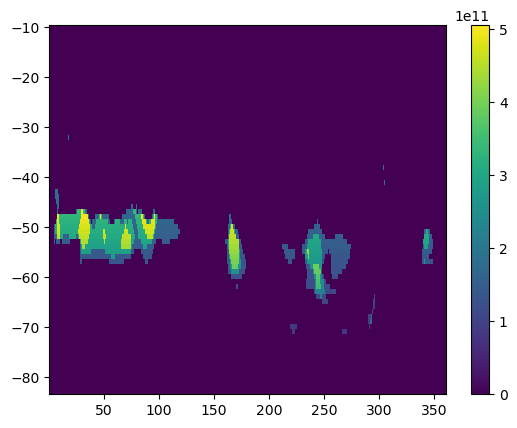

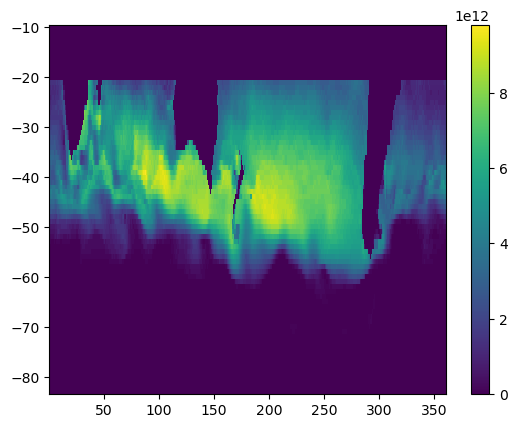

In [16]:
plt.figure()
plt.pcolormesh(samw_cub_volume.coords['lon'], samw_cub_volume.coords['lat'], samw_cub_volume.isel(time=0, depth=slice(0,5)).sum(dim='depth'))
plt.colorbar()

plt.figure()
plt.pcolormesh(samw_cub_volume.coords['lon'], samw_cub_volume.coords['lat'], samw_cub_volume.isel(time=0).sum(dim='depth'))
plt.colorbar()

In [17]:
%%time

samw_cub_volume.name = "SAMWvol"
samw_cub_volume.attrs['units'] = 'm3'
samw_cub_volume.to_netcdf("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_SAMWvol_cubic.nc")


CPU times: user 1.32 s, sys: 4.35 s, total: 5.67 s
Wall time: 5.19 s


## Assess the change in properties on the SAMW

CPU times: user 2.72 s, sys: 2.61 s, total: 5.33 s
Wall time: 3.94 s


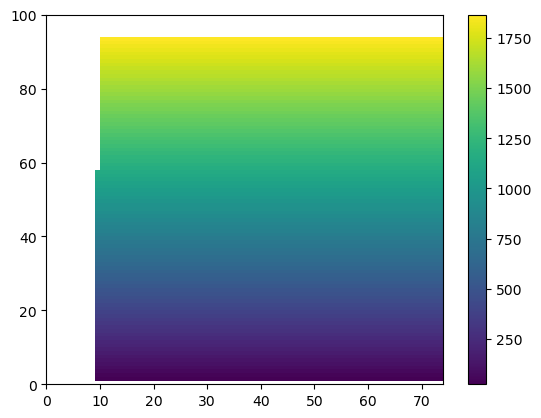

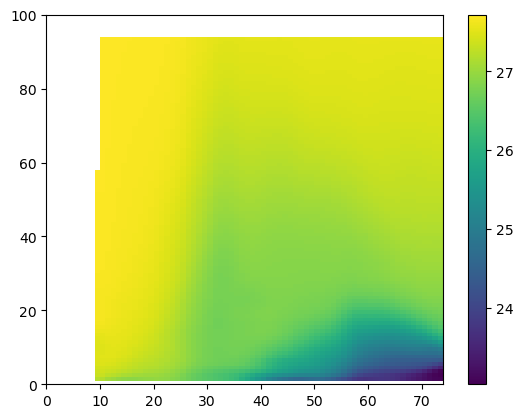

In [18]:
%%time

sh_dept_cub = sh_temp_cub * 0.0 + sh_temp_cub.coords['depth']
sh_dept_cub

plt.figure()
plt.pcolormesh(sh_dept_cub.isel(time=0).sel(lon=230.0, method='nearest'))
plt.colorbar()

plt.figure()
plt.pcolormesh(sh_rho0_cub.isel(time=0).sel(lon=230.0, method='nearest'))
plt.colorbar()


In [19]:
%%time

tem_samw = sh_temp_cub.where(samw_cub > 0.0, other=np.nan)
dep_samw = sh_dept_cub.where(samw_cub > 0.0, other=np.nan)
sal_samw = sh_salt_cub.where(samw_cub > 0.0, other=np.nan)

# find properties in the upper limb of SAMW (26.5 to 26.7 kg/m3)
tem_Usamw = sh_temp_cub.where((sh_rho0_cub > 26.5) & (sh_rho0_cub < 26.7), other=np.nan)
dep_Usamw = sh_dept_cub.where((sh_rho0_cub > 26.5) & (sh_rho0_cub < 26.7), other=np.nan)
sal_Usamw = sh_salt_cub.where((sh_rho0_cub > 26.5) & (sh_rho0_cub < 26.7), other=np.nan)

# find properties in the lower limb of SAMW (26.9 to 27.1 kg/m3)
tem_Lsamw = sh_temp_cub.where((sh_rho0_cub > 26.9) & (sh_rho0_cub < 27.1), other=np.nan)
dep_Lsamw = sh_dept_cub.where((sh_rho0_cub > 26.9) & (sh_rho0_cub < 27.1), other=np.nan)
sal_Lsamw = sh_salt_cub.where((sh_rho0_cub > 26.9) & (sh_rho0_cub < 27.1), other=np.nan)


CPU times: user 22.1 s, sys: 22.8 s, total: 44.9 s
Wall time: 37.3 s


In [20]:
%%time

dtem_samw = tem_samw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - tem_samw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
ddep_samw = dep_samw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - dep_samw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
dsal_samw = sal_samw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - sal_samw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)

dtem_Usamw = tem_Usamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - tem_Usamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
ddep_Usamw = dep_Usamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - dep_Usamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
dsal_Usamw = sal_Usamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - sal_Usamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)

dtem_Lsamw = tem_Lsamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - tem_Lsamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
ddep_Lsamw = dep_Lsamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - dep_Lsamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)
dsal_Lsamw = sal_Lsamw.isel(time=slice(-60,-1)).mean(dim=['time', 'depth'], skipna=True) - sal_Lsamw.isel(time=slice(0,60)).mean(dim=['time', 'depth'], skipna=True)


CPU times: user 24.1 s, sys: 11 s, total: 35 s
Wall time: 26.3 s


In [21]:
dtem_samw

<xarray.DataArray 'temperature' (lat: 74, lon: 360)> Size: 213kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(74, 360))
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0

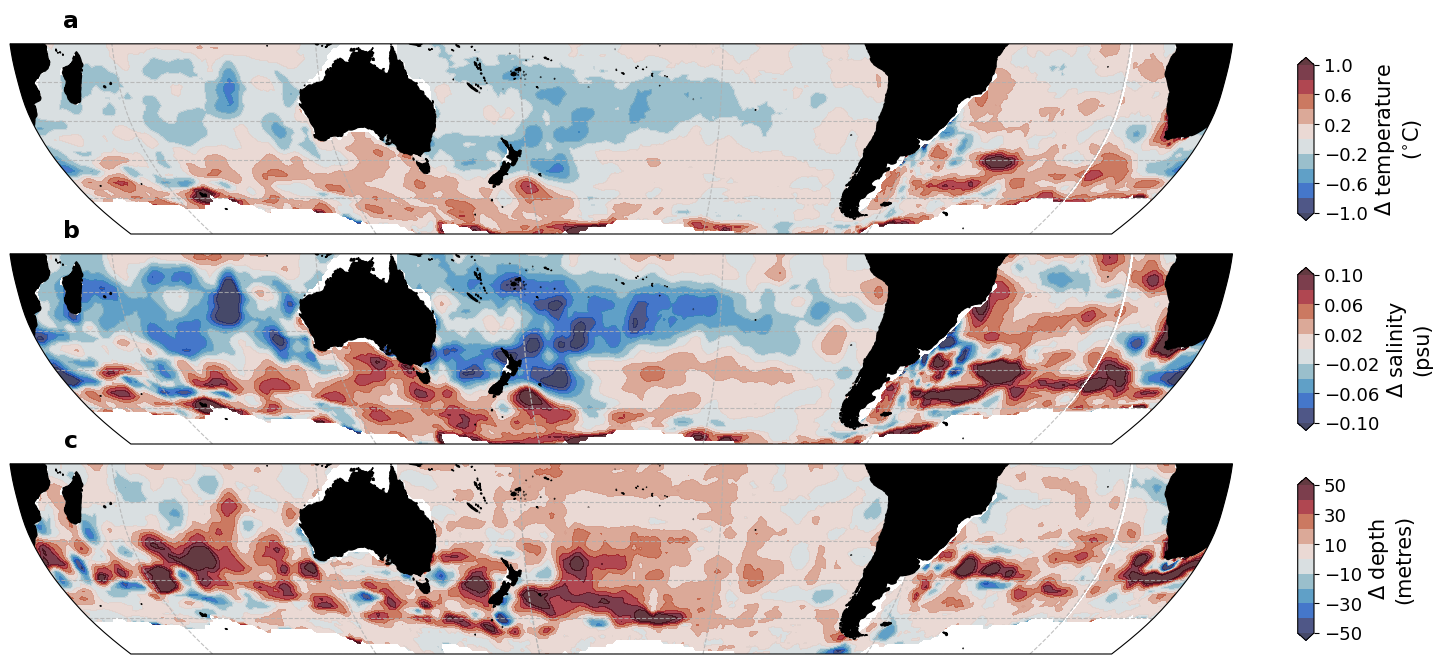

In [22]:
proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(-10,11,2)*0.1 # T
levs2 = np.arange(-10,11,2)*0.01 # S
levs3 = np.arange(-50,51,10) # Depth

colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(16,7), facecolor='w')
gs = GridSpec(3,1)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[1,0], projection=proj)
ax3 = plt.subplot(gs[2,0], projection=proj)

ax1.add_feature(cfeature.LAND, zorder=3, color='k')
ax2.add_feature(cfeature.LAND, zorder=3, color='k')
ax3.add_feature(cfeature.LAND, zorder=3, color='k')

ax1.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
ax2.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
ax3.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())

lons = dtem_Usamw.coords['lon']
lats = dtem_Usamw.coords['lat']

p1 = ax1.contourf(lons, lats, dtem_Usamw, transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap, vmin=np.min(levs1), vmax=np.max(levs1), extend='both')
p2 = ax2.contourf(lons, lats, dsal_Usamw, transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')
p3 = ax3.contourf(lons, lats, ddep_Usamw, transform=ccrs.PlateCarree(), levels=levs3, cmap=colmap, vmin=np.min(levs3), vmax=np.max(levs3), extend='both')

plt.subplots_adjust(left=0.05, right=0.865, top=0.95, bottom=0.05, hspace=0.0, wspace=0.0)


xx = 0.05; yy = 1.12
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax3.transAxes)


xx = 0.5; yy = 1.2
#plt.text(xx,yy,'Temperature', fontsize=fslab, va='center', ha='center', transform=ax1.transAxes, rotation=0)
#plt.text(xx,yy,'Salinity', fontsize=fslab, va='center', ha='center', transform=ax2.transAxes, rotation=0)
#plt.text(xx,yy,'Depth', fontsize=fslab, va='center', ha='center', transform=ax3.transAxes, rotation=0)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::2], aspect=10, fraction=0.0125) 
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::2], aspect=10, fraction=0.0125) 
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::2], aspect=10, fraction=0.0125)

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)
cbar3.ax.tick_params(labelsize=fstic)

cbar1.ax.set_ylabel('$\Delta$ temperature\n($^{\circ}$C)', fontsize=fslab)
cbar2.ax.set_ylabel('$\Delta$ salinity\n(psu)', fontsize=fslab)
cbar3.ax.set_ylabel('$\Delta$ depth\n(metres)', fontsize=fslab)

ax1.gridlines(linestyle='--', alpha=0.8)
ax2.gridlines(linestyle='--', alpha=0.8)
ax3.gridlines(linestyle='--', alpha=0.8)


In [23]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4_Usamw_changes.png', dpi=300, bbox_inches='tight')


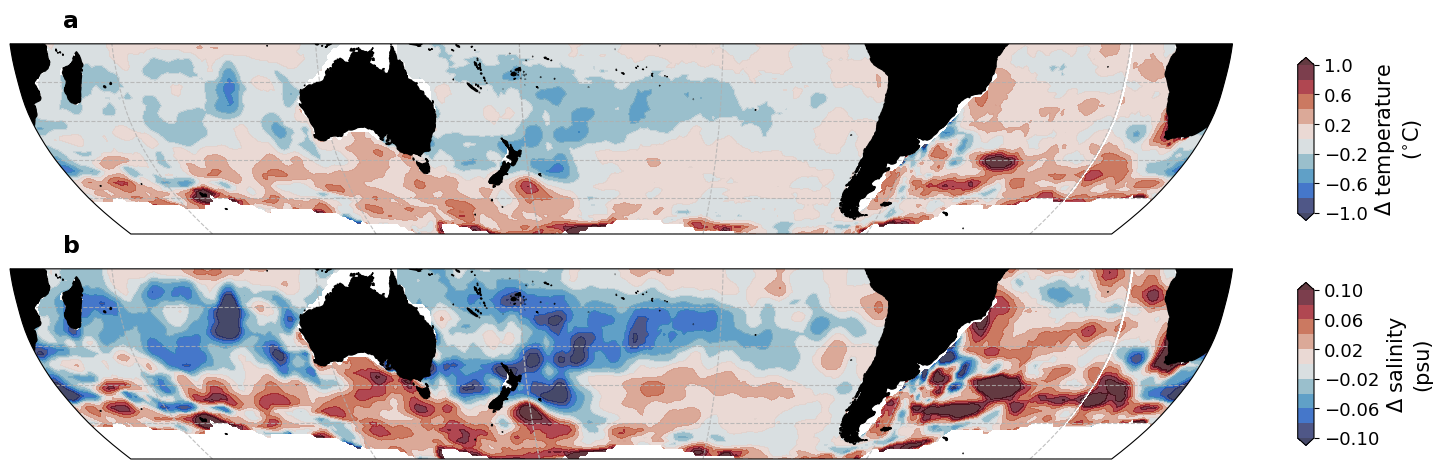

In [24]:
proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(-10,11,2)*0.1 # T
levs2 = np.arange(-10,11,2)*0.01 # S
levs3 = np.arange(-50,51,10) # Depth

colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(16,5), facecolor='w')
gs = GridSpec(2,1)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[1,0], projection=proj)
#ax3 = plt.subplot(gs[2,0], projection=proj)

ax1.add_feature(cfeature.LAND, zorder=3, color='k')
ax2.add_feature(cfeature.LAND, zorder=3, color='k')
#ax3.add_feature(cfeature.LAND, zorder=3, color='k')

ax1.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
ax2.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
#ax3.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())

lons = dtem_Usamw.coords['lon']
lats = dtem_Usamw.coords['lat']

p1 = ax1.contourf(lons, lats, dtem_Usamw, transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap, vmin=np.min(levs1), vmax=np.max(levs1), extend='both')
p2 = ax2.contourf(lons, lats, dsal_Usamw, transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')
#p3 = ax3.contourf(lons, lats, ddep_Usamw, transform=ccrs.PlateCarree(), levels=levs3, cmap=colmap, vmin=np.min(levs3), vmax=np.max(levs3), extend='both')

plt.subplots_adjust(left=0.05, right=0.865, top=0.95, bottom=0.05, hspace=0.0, wspace=0.0)


xx = 0.05; yy = 1.12
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
#plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax3.transAxes)


xx = 0.5; yy = 1.2
#plt.text(xx,yy,'Temperature', fontsize=fslab, va='center', ha='center', transform=ax1.transAxes, rotation=0)
#plt.text(xx,yy,'Salinity', fontsize=fslab, va='center', ha='center', transform=ax2.transAxes, rotation=0)
#plt.text(xx,yy,'Depth', fontsize=fslab, va='center', ha='center', transform=ax3.transAxes, rotation=0)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::2], aspect=10, fraction=0.0125) 
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::2], aspect=10, fraction=0.0125) 
#cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::2], aspect=10, fraction=0.0125)

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)
#cbar3.ax.tick_params(labelsize=fstic)

cbar1.ax.set_ylabel('$\Delta$ temperature\n($^{\circ}$C)', fontsize=fslab)
cbar2.ax.set_ylabel('$\Delta$ salinity\n(psu)', fontsize=fslab)
#cbar3.ax.set_ylabel('$\Delta$ depth\n(metres)', fontsize=fslab)

ax1.gridlines(linestyle='--', alpha=0.8)
ax2.gridlines(linestyle='--', alpha=0.8)
#ax3.gridlines(linestyle='--', alpha=0.8)


In [25]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4_Usamw_TSchanges.png', dpi=300, bbox_inches='tight')


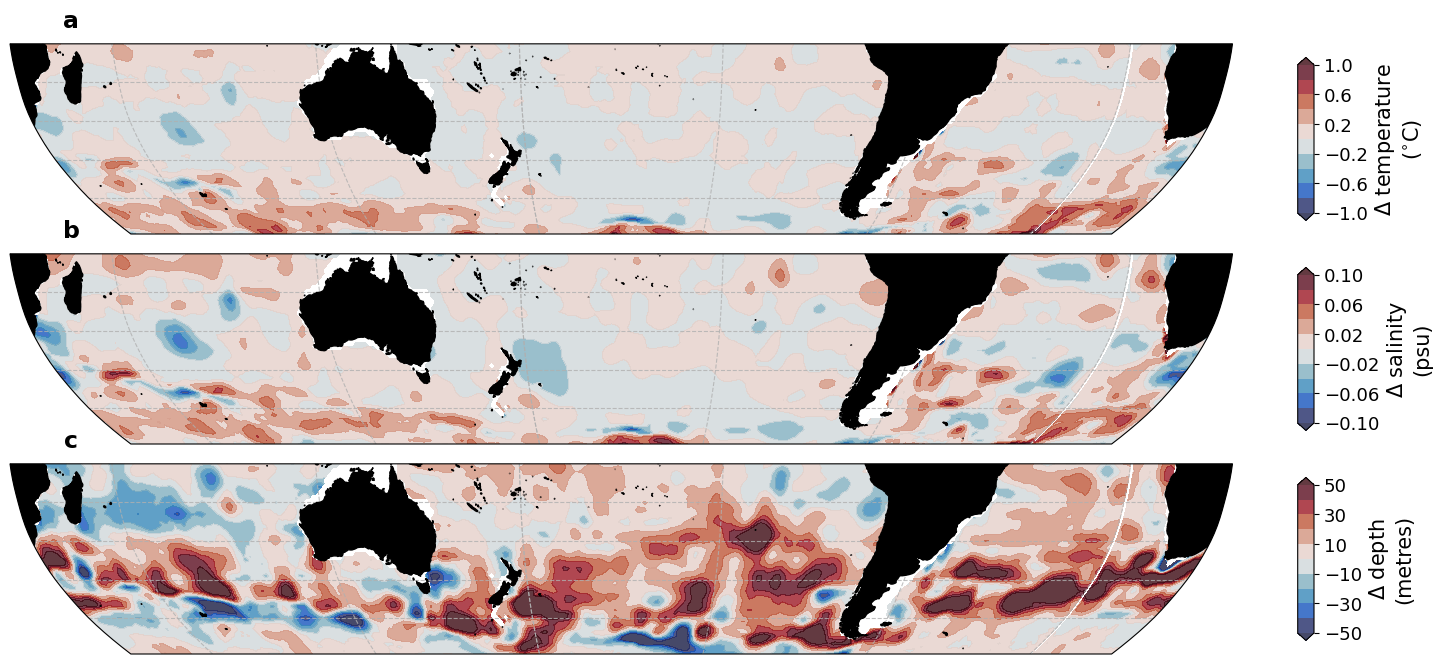

In [96]:
proj = ccrs.Robinson(central_longitude=210)

levs1 = np.arange(-10,11,2)*0.1 # T
levs2 = np.arange(-10,11,2)*0.01 # S
levs3 = np.arange(-50,51,10) # Depth

colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(16,7), facecolor='w')
gs = GridSpec(3,1)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[1,0], projection=proj)
ax3 = plt.subplot(gs[2,0], projection=proj)

ax1.add_feature(cfeature.LAND, zorder=3, color='k')
ax2.add_feature(cfeature.LAND, zorder=3, color='k')
ax3.add_feature(cfeature.LAND, zorder=3, color='k')

ax1.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
ax2.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())
ax3.set_extent([-180,180,-60,-10], crs=ccrs.PlateCarree())

lons = dtem_Usamw.coords['lon']
lats = dtem_Usamw.coords['lat']

p1 = ax1.contourf(lons, lats, dtem_Lsamw, transform=ccrs.PlateCarree(), levels=levs1, cmap=colmap, vmin=np.min(levs1), vmax=np.max(levs1), extend='both')
p2 = ax2.contourf(lons, lats, dsal_Lsamw, transform=ccrs.PlateCarree(), levels=levs2, cmap=colmap, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')
p3 = ax3.contourf(lons, lats, ddep_Lsamw, transform=ccrs.PlateCarree(), levels=levs3, cmap=colmap, vmin=np.min(levs3), vmax=np.max(levs3), extend='both')

plt.subplots_adjust(left=0.05, right=0.865, top=0.95, bottom=0.05, hspace=0.0, wspace=0.0)


xx = 0.05; yy = 1.12
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax3.transAxes)


xx = 0.5; yy = 1.2
#plt.text(xx,yy,'Temperature', fontsize=fslab, va='center', ha='center', transform=ax1.transAxes, rotation=0)
#plt.text(xx,yy,'Salinity', fontsize=fslab, va='center', ha='center', transform=ax2.transAxes, rotation=0)
#plt.text(xx,yy,'Depth', fontsize=fslab, va='center', ha='center', transform=ax3.transAxes, rotation=0)

cbar1 = plt.colorbar(p1, ax=ax1, orientation='vertical', ticks=levs1[::2], aspect=10, fraction=0.0125) 
cbar2 = plt.colorbar(p2, ax=ax2, orientation='vertical', ticks=levs2[::2], aspect=10, fraction=0.0125) 
cbar3 = plt.colorbar(p3, ax=ax3, orientation='vertical', ticks=levs3[::2], aspect=10, fraction=0.0125)

cbar1.ax.tick_params(labelsize=fstic)
cbar2.ax.tick_params(labelsize=fstic)
cbar3.ax.tick_params(labelsize=fstic)

cbar1.ax.set_ylabel('$\Delta$ temperature\n($^{\circ}$C)', fontsize=fslab)
cbar2.ax.set_ylabel('$\Delta$ salinity\n(psu)', fontsize=fslab)
cbar3.ax.set_ylabel('$\Delta$ depth\n(metres)', fontsize=fslab)

ax1.gridlines(linestyle='--', alpha=0.8)
ax2.gridlines(linestyle='--', alpha=0.8)
ax3.gridlines(linestyle='--', alpha=0.8)


In [98]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4_Lsamw_changes.png', dpi=300, bbox_inches='tight')


## Create SAMW volume changes in EN4

In [26]:
#samw_cub_volume = xr.open_dataset("/g/data/es60/pjb581/JRA55-NEMO-PISCES/EN4_SAMWvol_cubic.nc")
#samw_cub_volume = samw_cub_volume['SAMWvol']
samw_cub_volume


<xarray.DataArray 'SAMWvol' (time: 216, depth: 100, lat: 74, lon: 360)> Size: 5GB
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
...
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]], shape=(216, 100, 74, 360))
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time     (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T12:...
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Attributes:
    units:    m3

In [27]:
%%time

# put time on the first dimension
print("transposing")
samw_cub_volume = samw_cub_volume.transpose("time", "depth", "lat", "lon")

# reduce dimensions of datasets to regrid by removing time
print("removing time dimension by averaging")
samw_volume_start = samw_cub_volume.isel(time=slice(0,60)).mean(dim='time')
samw_volume_end = samw_cub_volume.isel(time=slice(-60,216)).mean(dim='time')
samw_volume_end


transposing
removing time dimension by averaging
CPU times: user 1.21 s, sys: 116 ms, total: 1.32 s
Wall time: 988 ms


<xarray.DataArray 'SAMWvol' (depth: 100, lat: 74, lon: 360)> Size: 21MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(100, 74, 360))
Coordinates:
  * lat      (lat) float32 296B -83.0 -82.0 -81.0 -80.0 ... -12.0 -11.0 -10.0
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985

In [28]:
%%time

import cartopy.util as cutil

print("Preparation for plotting")

### top down
samw_volume_start_area = samw_volume_start.sum(dim='depth')
samw_volume_end_area = samw_volume_end.sum(dim='depth')

### from the front
samw_volume_start_front = samw_volume_start.sum(dim='lat')
samw_volume_end_front = samw_volume_end.sum(dim='lat')

### from the side of each basin
#samw_volume_start_pacside = samw_volume_start.where(samw_volume_start.coords['lon'] > 150.0, other=0.0).where(samw_volume_start.coords['lon'] < 300.0, other=0.0).sum(dim='lon')
#samw_volume_end_pacside = samw_volume_end.where(samw_volume_end.coords['lon'] > 150.0, other=0.0).where(samw_volume_end.coords['lon'] < 300.0, other=0.0).sum(dim='lon')

samw_volume_start_pacside = samw_volume_start.sel(lon=slice(150.0, 300.0)).sum(dim='lon')
samw_volume_end_pacside = samw_volume_end.sel(lon=slice(150.0, 300.0)).sum(dim='lon')
samw_volume_start_indside = samw_volume_start.sel(lon=slice(30.0, 150.0)).sum(dim='lon')
samw_volume_end_indside = samw_volume_end.sel(lon=slice(30.0, 150.0)).sum(dim='lon')
samw_volume_start_atlside = samw_volume_start.where(samw_volume_start.coords['lon'] > 300.0, other=0.0).sum(dim='lon') + samw_volume_start.where(samw_volume_start.coords['lon'] < 30.0, other=0.0).sum(dim='lon')
samw_volume_end_atlside = samw_volume_end.where(samw_volume_end.coords['lon'] > 300.0, other=0.0).sum(dim='lon') + samw_volume_end.where(samw_volume_end.coords['lon'] < 30.0, other=0.0).sum(dim='lon')

### wrap the longitudes for the top-down and from-the-front arrays
#samw_volume_start_area = xr.DataArray(
#    samw_volume_start_area,
#    dims=("y", "x"),
#    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
#            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
#            }
#    )
#samw_volume_end_area = xr.DataArray(
#    samw_volume_end_area,
#    dims=("y", "x"),
#    coords={"lon": (['x'], ds_out.coords['lon'].isel(y=0).values),
#            "lat": (['y'], ds_out.coords['lat'].isel(x=0).values),
#            }
#    )


samw_volume_start_area_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_volume_start_area, coord=samw_volume_start_area.coords['lon'])
samw_volume_end_area_wrapped, lon_reg_wrapped = cutil.add_cyclic_point(samw_volume_end_area, coord=samw_volume_end_area.coords['lon'])

samw_volume_sum = samw_cub_volume.sum(dim=['depth','lat','lon']) * 1e-12
samw_volume_pac_sum = samw_cub_volume.sel(lon=slice(150.0, 300.0)).sum(dim=['depth','lat','lon']) * 1e-12
samw_volume_ind_sum = samw_cub_volume.sel(lon=slice(30.0, 150.0)).sum(dim=['depth','lat','lon']) * 1e-12
samw_volume_atl_sum = (samw_cub_volume.sel(lon=slice(0.0, 30.0)).sum(dim=['depth','lat','lon']) + samw_cub_volume.sel(lon=slice(300.0, 360.0)).sum(dim=['depth','lat','lon'])) * 1e-12


Preparation for plotting
CPU times: user 8.94 s, sys: 8.43 s, total: 17.4 s
Wall time: 13 s


Text(-0.5, 0.5, '2018-2022\nminus\n2005-2009')

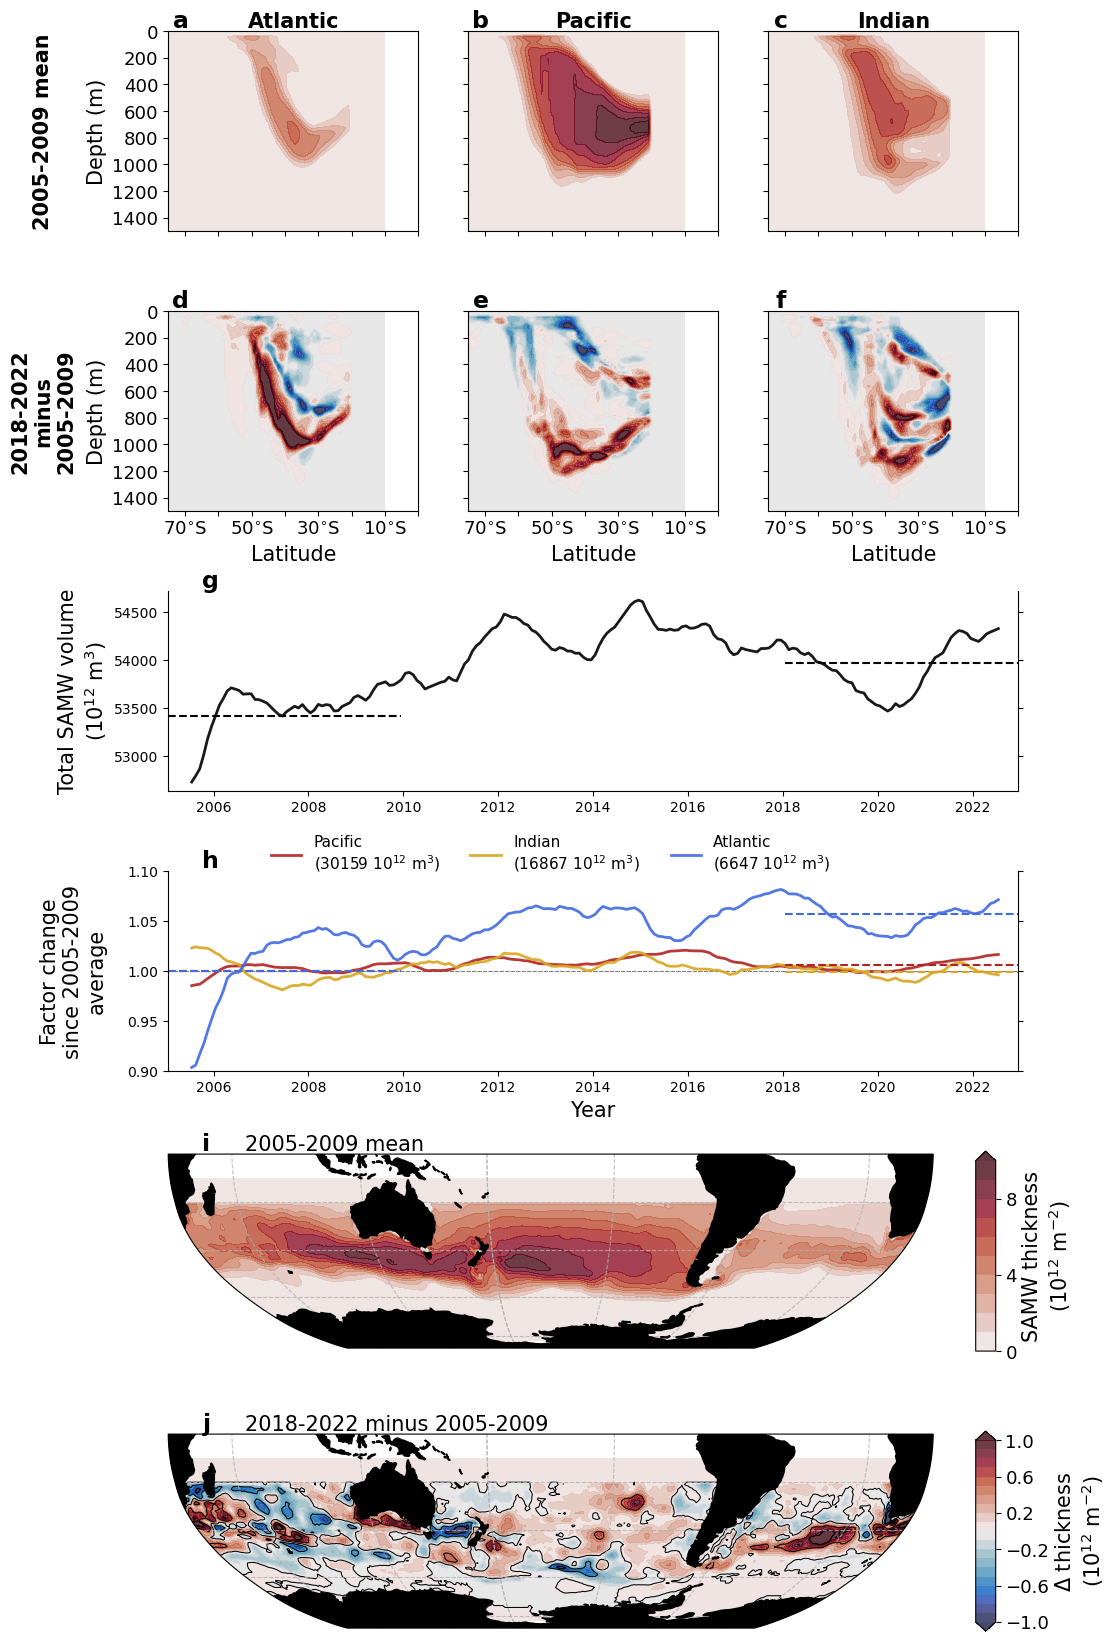

In [30]:
proj = ccrs.Robinson(central_longitude=210)

time = samw_cub_volume.coords['time']
depths = samw_volume_start_atlside.coords['depth']
lats = samw_volume_start_atlside.coords['lat']

levs1 = np.arange(0,101,10)*0.3
levs2 = np.arange(-10,11,1)*0.2
levs9 = np.arange(0,11,1)
levs10 = np.arange(-1,1.1,0.1)

colmap1 = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15

fig = plt.figure(figsize=(10,20), facecolor='w')
gs = GridSpec(6,3)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[0,2])
ax4 = plt.subplot(gs[1,0])
ax5 = plt.subplot(gs[1,1])
ax6 = plt.subplot(gs[1,2])
ax7 = plt.subplot(gs[2,:])
ax8 = plt.subplot(gs[3,:])
ax9 = plt.subplot(gs[4,:], projection=proj)
ax10 = plt.subplot(gs[5,:], projection=proj)

ax9.add_feature(cfeature.LAND, zorder=3, color='k')
ax10.add_feature(cfeature.LAND, zorder=3, color='k')
ax9.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())
ax10.set_extent([-180,180,-90,0], crs=ccrs.PlateCarree())

ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False, labelleft=False)
ax3.tick_params(labelbottom=False, labelleft=False)
ax5.tick_params(labelleft=False)
ax6.tick_params(labelleft=False)
ax7.tick_params(right=True)
ax8.tick_params(right=True)

ax7.spines[['top']].set_visible(False)
ax8.spines[['top']].set_visible(False)


p1 = ax1.contourf(lats, depths, samw_volume_start_atlside * 1e-12, levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')
p2 = ax2.contourf(lats, depths, samw_volume_start_pacside * 1e-12, levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')
p3 = ax3.contourf(lats, depths, samw_volume_start_indside * 1e-12, levels=levs1, cmap=colmap1, vmin=np.min(levs1), vmax=np.max(levs1), extend='max')

p4 = ax4.contourf(lats, depths, (samw_volume_end_atlside - samw_volume_start_atlside) * 1e-12, levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')
p5 = ax5.contourf(lats, depths, (samw_volume_end_pacside - samw_volume_start_pacside) * 1e-12, levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')
p6 = ax6.contourf(lats, depths, (samw_volume_end_indside - samw_volume_start_indside) * 1e-12, levels=levs2, cmap=colmap2, vmin=np.min(levs2), vmax=np.max(levs2), extend='both')

lwid = [1.0, 2.0, 2.0, 2.0]
cols = ['k', 'k']
lsty = ['-', '-']
alfs = 0.9

#ax7.plot(time, samw_volume_sum, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
ax7.plot(time, samw_volume_sum.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1])
ax7.plot(time[0:60], np.ones((60))*samw_volume_sum.isel(time=slice(0,60)).mean(dim='time').values, 'k--')
ax7.plot(time[-60::], np.ones((60))*samw_volume_sum.isel(time=slice(-60,216)).mean(dim='time').values, 'k--')

samw_volume_pac_per = (samw_volume_pac_sum / samw_volume_pac_sum.isel(time=slice(0,60)).mean(dim="time"))
samw_volume_ind_per = (samw_volume_ind_sum / samw_volume_ind_sum.isel(time=slice(0,60)).mean(dim="time"))
samw_volume_atl_per = (samw_volume_atl_sum / samw_volume_atl_sum.isel(time=slice(0,60)).mean(dim="time"))


cols = ['firebrick', 'goldenrod', 'royalblue']
lab = ['Pacific\n(%d 10$^{12}$ m$^{3}$)'%(samw_volume_pac_sum.isel(time=slice(0,60)).mean(dim='time')), \
       'Indian\n(%d 10$^{12}$ m$^{3}$)'%(samw_volume_ind_sum.isel(time=slice(0,60)).mean(dim='time')), \
       'Atlantic\n(%d 10$^{12}$ m$^{3}$)'%(samw_volume_atl_sum.isel(time=slice(0,60)).mean(dim='time'))]

#ax8.plot(time, samw_volume_pac_per, color=cols[0], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
#ax8.plot(time, samw_volume_ind_per, color=cols[1], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])
#ax8.plot(time, samw_volume_atl_per, color=cols[2], linewidth=lwid[0], alpha=alfs, linestyle=lsty[0])

ax8.plot(time, np.ones(len(time))*samw_volume_pac_per.isel(time=slice(0,60)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_ind_per.isel(time=slice(0,60)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')
ax8.plot(time, np.ones(len(time))*samw_volume_atl_per.isel(time=slice(0,60)).mean(dim='time').values, color='grey', linewidth=0.75, alpha=1.0, linestyle='--')

ax8.plot(time, samw_volume_pac_per.rolling(time=12, center=True).mean(), color=cols[0], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[0])
ax8.plot(time, samw_volume_ind_per.rolling(time=12, center=True).mean(), color=cols[1], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[1])
ax8.plot(time, samw_volume_atl_per.rolling(time=12, center=True).mean(), color=cols[2], linewidth=lwid[1], alpha=alfs, linestyle=lsty[1], label=lab[2])

ax8.plot(time[0:60], np.ones((60))*samw_volume_pac_per.isel(time=slice(0,60)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[-60::], np.ones((60))*samw_volume_pac_per.isel(time=slice(-60,216)).mean(dim='time').values, linestyle='--', color=cols[0])
ax8.plot(time[0:60], np.ones((60))*samw_volume_ind_per.isel(time=slice(0,60)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[-60::], np.ones((60))*samw_volume_ind_per.isel(time=slice(-60,216)).mean(dim='time').values, linestyle='--', color=cols[1])
ax8.plot(time[0:60], np.ones((60))*samw_volume_atl_per.isel(time=slice(0,60)).mean(dim='time').values, linestyle='--', color=cols[2])
ax8.plot(time[-60::], np.ones((60))*samw_volume_atl_per.isel(time=slice(-60,216)).mean(dim='time').values, linestyle='--', color=cols[2])

p9 = ax9.contourf(lon_reg_wrapped,lats, samw_volume_start_area_wrapped*1e-12, transform=ccrs.PlateCarree(), levels=levs9, cmap=colmap1, vmin=np.min(levs9), vmax=np.max(levs9), extend='max')
p10 = ax10.contourf(lon_reg_wrapped,lats, (samw_volume_end_area_wrapped - samw_volume_start_area_wrapped)*1e-12, transform=ccrs.PlateCarree(), levels=levs10, cmap=colmap2, vmin=np.min(levs10), vmax=np.max(levs10), extend='both')
c10 = ax10.contour(lon_reg_wrapped,lats, (samw_volume_end_area_wrapped - samw_volume_start_area_wrapped)*1e-12, transform=ccrs.PlateCarree(), levels=levs10[::5], linestyles='-', linewidths=0.75, colors='k')


x1 = -75; x2 = 0
y1 = 1500; y2 = 0
ax1.set_xlim(x1,x2); ax1.set_ylim(y1,y2)
ax2.set_xlim(x1,x2); ax2.set_ylim(y1,y2)
ax3.set_xlim(x1,x2); ax3.set_ylim(y1,y2)
ax4.set_xlim(x1,x2); ax4.set_ylim(y1,y2)
ax5.set_xlim(x1,x2); ax5.set_ylim(y1,y2)
ax6.set_xlim(x1,x2); ax6.set_ylim(y1,y2)

x1 = np.arange(-70,1,10); x2 = np.array(["70$^{\circ}$S", " ", "50$^{\circ}$S", " ", "30$^{\circ}$S", " ", "10$^{\circ}$S", " " ])
y1 = np.arange(1400,-1,-200); y2 = np.arange(1400,-1,-200)
ax1.set_xticks(x1,x2, fontsize=fstic); ax1.set_yticks(y1,y2, fontsize=fstic)
ax2.set_xticks(x1,x2, fontsize=fstic); ax2.set_yticks(y1,y2, fontsize=fstic)
ax3.set_xticks(x1,x2, fontsize=fstic); ax3.set_yticks(y1,y2, fontsize=fstic)
ax4.set_xticks(x1,x2, fontsize=fstic); ax4.set_yticks(y1,y2, fontsize=fstic)
ax5.set_xticks(x1,x2, fontsize=fstic); ax5.set_yticks(y1,y2, fontsize=fstic)
ax6.set_xticks(x1,x2, fontsize=fstic); ax6.set_yticks(y1,y2, fontsize=fstic)

xx = 0.5; yy = 1.05
plt.text(xx,yy,'Atlantic', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy,'Pacific', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy,'Indian', fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax3.transAxes)

ax1.set_ylabel("Depth (m)", fontsize=fslab)
ax4.set_ylabel("Depth (m)", fontsize=fslab)
ax4.set_xlabel("Latitude", fontsize=fslab)
ax5.set_xlabel("Latitude", fontsize=fslab)
ax6.set_xlabel("Latitude", fontsize=fslab)

ax7.set_xlim(time[0],time[-1])
ax8.set_xlim(time[0],time[-1])
#ax7.set_ylim(43000,47000)
ax8.set_ylim(0.9,1.1)
ax8.set_xlabel("Year", fontsize=fslab)
ax7.set_ylabel("Total SAMW volume\n(10$^{12}$ m$^{3}$)", fontsize=fslab)
ax8.set_ylabel("Factor change\nsince 2005-2009\naverage", fontsize=fslab, labelpad=15)
ax8.legend(loc='upper center', frameon=False, fontsize=fstic-2, ncol=3, bbox_to_anchor=(0.45,1.25))


cbar9 = plt.colorbar(p9, ax=ax9, orientation='vertical', ticks=levs9[::4], fraction=0.05, aspect=10, pad=0.05)
cbar10 = plt.colorbar(p10, ax=ax10, orientation='vertical', ticks=levs10[::4], fraction=0.05, aspect=10, pad=0.05)
cbar9.ax.set_ylabel("SAMW thickness\n(10$^{12}$ m$^{-2}$)", fontsize=fslab)
cbar10.ax.set_ylabel("$\Delta$ thickness\n(10$^{12}$ m$^{-2}$)", fontsize=fslab)
cbar9.ax.tick_params(labelsize=fstic)
cbar10.ax.tick_params(labelsize=fstic)

plt.subplots_adjust(left=0.05, top=0.9, bottom=0.1, hspace=0.4)

ax9.gridlines(linestyle='--', alpha=0.8)
ax10.gridlines(linestyle='--', alpha=0.8)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontsize=fslab+2, va='center', ha='center', fontweight='bold', transform=ax10.transAxes)

xx = 0.05; yy = 1.05
plt.text(xx*2,yy,"2005-2009 mean", fontsize=fslab, va='center', ha='left', transform=ax9.transAxes)
plt.text(xx*2,yy,"2018-2022 minus 2005-2009", fontsize=fslab, va='center', ha='left', transform=ax10.transAxes)

xx = -0.5; yy = 0.5
plt.text(xx,yy,"2005-2009 mean", fontsize=fslab, va='center', ha='center', fontweight='bold', transform=ax1.transAxes, rotation=90)
plt.text(xx,yy,"2018-2022\nminus\n2005-2009", fontsize=fslab, va='center', fontweight='bold', ha='center', transform=ax4.transAxes, rotation=90)


In [31]:
%%time
    
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4samw_cub_change_2005-2022.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4samw_cub_change_2005-2022.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4samw_cub_change_2005-2022_trans.png', dpi=300, bbox_inches='tight', transparent=True)
